# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [123]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [124]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv') #completa el código

In [125]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [126]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [127]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [128]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [129]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [130]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [131]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [132]:
# cantidad de nulos para users

print(users.isna().sum())# Cantidad de valores nulos)
print(users.isna().mean())# Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [133]:
# cantidad de nulos para usage
print(usage.isna().sum())# Cantidad de valores nulos)
print(usage.isna().mean())# Proporción de valores nulos)


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.


- ### Para `users`:
   - city: puede buscarse la imputación devido a la proporción de 11.72%

   - churn_date: la tasa de churn_date nos indica los clientes que aún no cancelan y tienen pendiente una fecha de término, es decir, los clientes activos que es nuestro caso de estudio. Por lo tanto no tiene inferencia usar la columna y se puede eliminar.

- ### Para `usage`:
- date: con base en su tasa podemos nulificar el dato, tambien por la naturaleza del estudio, es un dato irrelevante.

- duration: en este caso los nulos estan indicando valores que no corresponden a lo que se esta midiendo (duración de un mensaje de texto) se podia cruzar la metrica correspondiente a cada valor para reducir o eliminar nulos (valor ausente MAR)

  - lenght: en este caso los nulos estan indicando valores que no corresponden a lo que se esta midiendo (numero de caracteres de una llamada) se podia cruzar la metrica correspondiente a cada valor para reducir o eliminar nulos (valor ausente MAR)



💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [134]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000



- ### Los datos de la columna user_id:

  - Son un identificador único de un cliente, puede usarse para tomar en cuenta registros unicos y ser mas afín con el origen de los datos, sin embargo no otorga información relevante para analizar uso o para tener datos que infieran en reformular mi oferta comercial, por lo tanto no tiene caso tomar en cuenta esa información para cálculos estadísticos y podemos omitirlo

- ### El valor minimo se ve reflejado como -999:

  - Al integrar analisis estadistico sesgaría a datos negativos, por lo tanto sería incorrecto

In [135]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- ### Las columnas `id` y `user_id`:
  1.- no tienen utilidad para mediciones estadisticas, ya que no me diria nada significativo sobre el comportamiento de los clientes
  2.-el objetivo de esos 2 datos combinados me ayudara para identificar cuantos eventos por usuario existen.
- ### Las columnas `duration` y `lenght`
  - En ambos casos las columnas presentan maximos atipicos (120min para duration y 1490caracteres para lenght), por lo tanto definimos nuestro limite superior lenght (Q3)64 + 1.5 × 27(IQR) = 104.5 y limite superior duration (Q3)6.99 + 1.5 x 5.56(IQR) = 15.33 (duration 104.5min y length 15.31caracteres ) siendo un 12.92% sobre el limite superior para duration y 98.97% sobre el limite superior de lenght (caso mas significativo) concluimos que en ambos casos presentamos outliers

In [136]:

# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[['city','plan']].value_counts()


city      plan   
Bogotá    Basico     522
CDMX      Basico     474
Medellín  Basico     398
GDL       Basico     298
Bogotá    Premium    286
MTY       Basico     275
Cali      Basico     262
CDMX      Premium    256
Medellín  Premium    218
Cali      Premium    162
GDL       Premium    152
MTY       Premium    132
?         Basico      65
          Premium     31
dtype: int64

- ### La columna `city`:
- hay 2 ciudades no definidas, una de ellas con valor sentinel.
- ### La columna `plan`:
- hay 65 usuarios plan basico y 31 plan premium que no esta definida su ubicación. total de 96

In [137]:

# explorar columna categórica de usage
usage.columns
usage['type'].describe()

 # completa el código

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- ### La columna `type`
- De los 40,000 datos hay 2 valores únicos que en este caso son "call" y "text", siendo este último el mas frecuente con 22,092 datos. para call serán 40,000-22,092=17,908 haciendo una comparativa de los datos que tengo de duration (17,924) y lenght (22,104), se encuentra una diferencia de 12 para text y 16 en call. por lo tanto se infiere en que no es una diferencia significativa para actuar sobre esos sentinels. 

---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- ¿Qué acción tomarías?

- ### Para users:
 - en la columna city con "?" es un sentinel que puede ser reemplazado por nulo, ya que el usuario aun tiene datos de age y plan, validos. En la columna age un valor sentinel -999 que debera ser reemplazado por la mediana.
- ### Para usage:
- tanto para duration como length el minimo es 0, no tiene caso mantener datos de mensajes vacios o llamadas no conectadas porque no nos da datos de comportamiento del usuario. 


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [138]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce') # completa el código

In [139]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [140]:

# Revisar los años presentes en `reg_date` de users
print(users['reg_date'].dt.year.value_counts().sort_index())


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, ... el registro de los usuarios va de 2022 a 2024, sin embargo se ven 40 usuarios en 2026 pueden ser errores de captura.

In [141]:
# Revisar los años presentes en `date` de usage
print(usage['date'].dt.year.value_counts().sort_index())

2024.0    39950
Name: date, dtype: int64


En `date`, el registro de uso de los usuarios solo compete el 2024
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?
- ### Para los 40 registros del año 2026:
 -  se puede hacer una sustitucion del año 2026 por null, para conservar los datos de utilidad que tiene ese registro sin eliminarlos por el hecho de estar incorrecto el año. Conservar la mayoria de datos correctos dara precision a nuestro analisis.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [142]:

# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan) # primero reemplazar el sentinel por nulos para sacar la mediana correcta
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()


count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [143]:
# Reemplazar ? por NA en city
users['city'] = users ['city'].replace('?',pd.NA)

# Verificar cambios
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [144]:

# Marcar fechas futuras como NA para reg_date
users['reg_date'] = users['reg_date'].where(users['reg_date'].dt.year <= 2024, other=pd.NaT)

# Verificar cambios
print(users['reg_date'].isna().sum())


40


### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [145]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())

type
call        0
text    22076
Name: duration, dtype: int64

In [146]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())

type
call    17896
text        0
Name: length, dtype: int64


### Diagnostico de nulos en `duration` y `length`

- Se encontró que la ausencia depende completamente de type, es decir, no corresponde el registro con la métrica en los nulos de ambos casos. También se concluye que es una variable observable y que no se comporta de manera aleatoria, por lo tanto es MAR. La acción a tomar es mantenerlos como nulos, porque excepto por el factor type, los datos son de valor y se acerca mas a la realidad mantenerlos. en resumen: Los nulos en duration aparecen únicamente en registros de tipo text / Los nulos en length aparecen únicamente en registros de tipo call / La ausencia depende completamente de la variable type (observable) / La decisión de mantenerlos como nulos es la correcta, ya que la métrica simplemente no aplica para ese tipo de registro


---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [147]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes

usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas




# Agrupar información por usuario
usage_agg = usage.groupby('user_id')\
    .agg(cant_mensajes=('is_text','sum'),
         cant_llamadas=('is_call','sum'),
         cant_minutos_llamada=('duration','sum'))\
    .reset_index()


# observar resultado
usage_agg.head(5)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74
3,10003,11,3,8.99
4,10004,4,3,8.01


In [148]:
# Renombrar columnas
usage_agg= usage_agg.rename(columns={
    'cant_mensajes':'mensajes_enviados',
    'cant_llamadas':'llamadas_realizadas',
    'cant_minutos_llamada':'minutos_de_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,mensajes_enviados,llamadas_realizadas,minutos_de_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [149]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg,on='user_id',how='inner')
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,mensajes_enviados,llamadas_realizadas,minutos_de_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [150]:

# Resumen estadístico de las columnas numéricas
user_profile.describe()


,user_id,age,mensajes_enviados,llamadas_realizadas,minutos_de_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000
mean,11999.729432,48.138285,5.524381,4.478120,23.317054
std,1154.898108,17.691541,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.500000,33.000000,4.000000,3.000000,11.120000
50%,12000.000000,48.000000,5.000000,4.000000,19.780000
75%,12999.500000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [151]:

# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100


Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

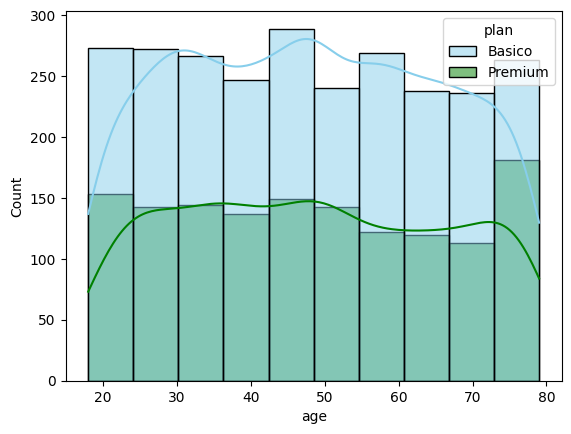

In [152]:
# Histograma para visualizar la edad (age)
sns.histplot(data=user_profile,x='age',bins=10,hue='plan',palette=['skyblue','green'],kde=True)
plt.show()

💡Insights: 
## Distribución:
- La distribución de edad presenta un sesgo positivo (hacia la derecha), con la mayor concentración de usuarios entre los 20 y 40 años. Al segmentar por plan, emerge un patrón claro: los usuarios de 20 a 40 años se inclinan predominantemente hacia el plan básico, mientras que los mayores de 40 años adoptan con mayor frecuencia el plan premium.
Este comportamiento sugiere una correlación entre edad y capacidad adquisitiva: a mayor edad, mayor disposición o posibilidad de pagar por un plan de mayor valor.
## Estrategia
El segmento joven (20–40 años) representa una oportunidad de conversión no explotada. Dado que su baja adopción del plan premium parece estar asociada a una barrera económica más que a falta de interés, una estrategia de precio diferenciado podría ser efectiva, por ejemplo:

#### Descuento por edad o perfil joven
#### Plan premium con entrada escalonada (precio menor el primer año)
#### Prueba gratuita extendida para usuarios menores de 35 años

## Conclusión
Reducir la fricción económica en el segmento joven es la palanca más directa para expandir la base premium, sin necesidad de modificar el producto ni afectar el precio para los segmentos que ya convierten de forma natural.

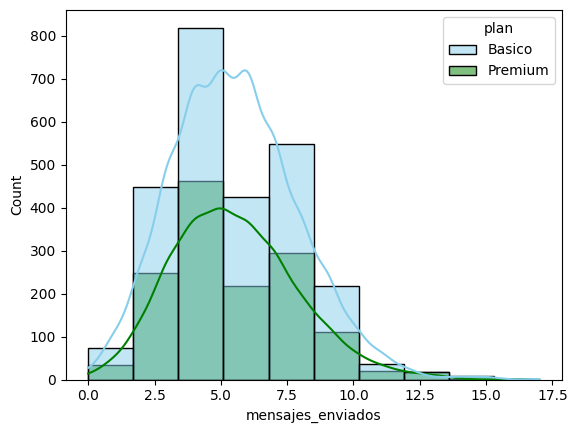

In [153]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data=user_profile,x='mensajes_enviados',bins=10,hue='plan',palette=['skyblue','green'],kde=True)
plt.show()

💡Insights: 
### Histograma `mensajes_enviados`:
- Refleja una distribución positiva o con sesgo a la derecha. La mayoría de los usuarios concentran un uso de mensajes entre 3 y 8 mensajes, el volumen cae drasticamente a partir de los 10 mensajes. El plan básico predomina en todos los servicios por el volumen de usuarios, sin embargo, los usuarios premium extienden mas la curva lo que da mayor variabilidad a su uso. Como conclusión ambos grupos tienen uso moderado de este servicio lo que significa que no es un diferenciador relevante entre planes. 

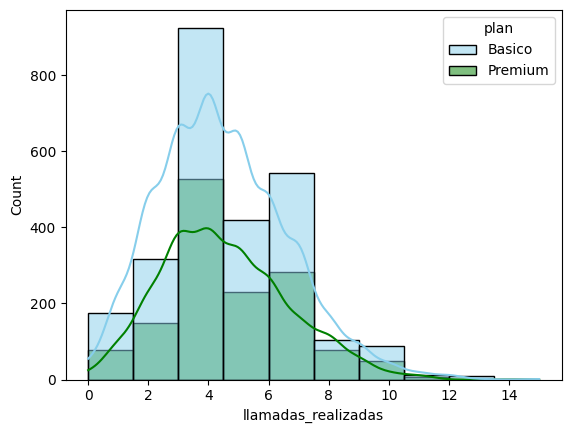

In [154]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data=user_profile,x='llamadas_realizadas',bins=10,hue='plan',palette=['skyblue','green'],kde=True)
plt.show()


💡Insights: 
- ### Histograma `llamadas_realizadas`:
- Refleja una distribucion positiva o con sesgo a la derecha. La mayoria de los usuarios concentran un uso de llamadas entre 3 y 7 llamadas, el volumen cae drasticamente a partir de 8 llamadas. El plan básico predomina en todos los servicios por el volumen de usuarios, sin embargo, los usuarios premium extienden mas la corva lo que da mayor variabilidad a su uso. Como conclusión ambos grupos tienen uso moderado de este servicio, sin embargo cabe resaltar que los usuarios premium tienden a un mayor numero de llamadas. 

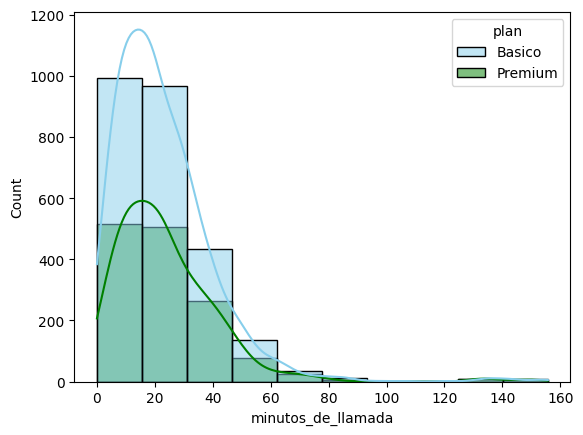

In [155]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data=user_profile,x='minutos_de_llamada',bins=10,hue='plan',palette=['skyblue','green'],kde=True)
plt.show()

💡Insights: 
- ### Histograma `minutos_de_llamada`:
-  Refleja una distribucion positiva o con sesgo a la derecha. La mayoria de los usuarios concentran un uso de minutos entre 0 y 60 min, el volumen cae drasticamente a partir de 63 min. En el plan basico su pico mas elevado es entre 0 y 10 min lo que significa que sus usuarios hacen llamadas mas cortas. la curva para usuarios premium se extiende un poco mas de 0 a 20min y tienen una distribución mas amplia, es decir, tienen mayor variabilidad en los tiempos de llamada extendiendose casi a los 160min. Por lo tanto podemos concluir que el uso de minutos en llamadas si puede ser un diferenciador mas para orientar una campaña de uso a usuarios de plan basico que tengan alto consumo en minutos, ya que su comportamiento corresponde al de uso premium. 

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

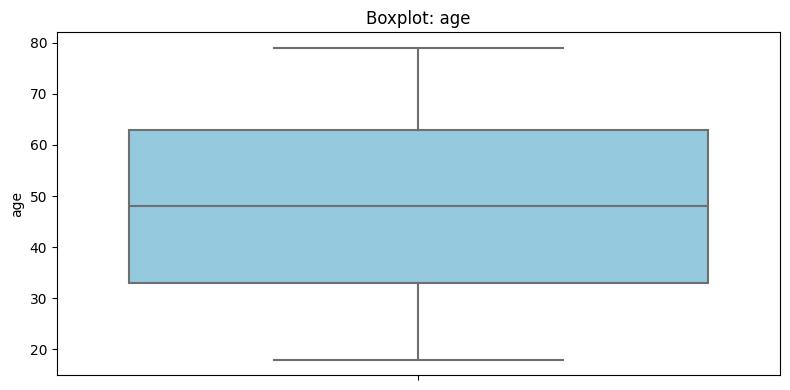

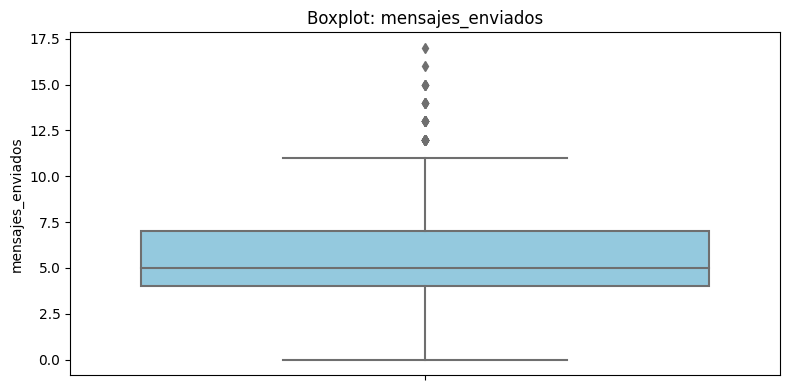

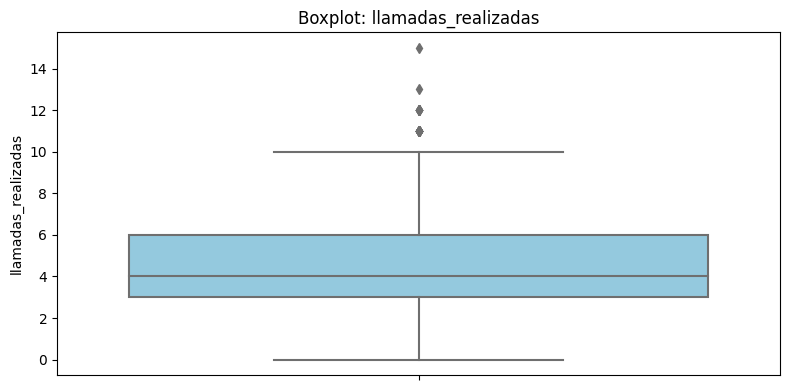

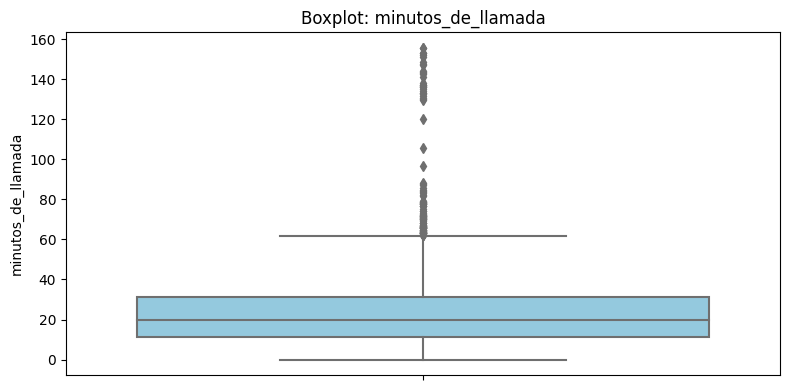

In [156]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'mensajes_enviados', 'llamadas_realizadas', 'minutos_de_llamada']
for col in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=user_profile, y=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.tight_layout()
    plt.show()


💡Insights: 
- Age: ...(no presenta outliers)
- cant_mensajes: presenta outliers a partir de los 12 mensajes
- cant_llamadas: presenta outliers a partir de las 11 llamadas
- cant_minutos_llamada: a partir de una hora presenta outliers


In [157]:

# Calcular límites con el método IQR
columnas_limites = ['mensajes_enviados','llamadas_realizadas','minutos_de_llamada']
columnas_limites=['mensajes_enviados','llamadas_realizadas','minutos_de_llamada']
for col in columnas_limites:

  Q1=user_profile[col].quantile(0.25)
  Q2=user_profile[col].quantile(0.50)
  Q3=user_profile[col].quantile(0.75)
  IQR= Q3-Q1
  limite_superior=Q3+1.5*IQR

  print(f"Columna: {col},Q1:{Q1},\Q2:{Q2},Q3:{Q3},IQR:{IQR},limite_superior:{limite_superior}")



Columna: mensajes_enviados,Q1:4.0,\Q2:5.0,Q3:7.0,IQR:3.0,limite_superior:11.5
Columna: llamadas_realizadas,Q1:3.0,\Q2:4.0,Q3:6.0,IQR:3.0,limite_superior:10.5
Columna: minutos_de_llamada,Q1:11.12,\Q2:19.78,Q3:31.415,IQR:20.295,limite_superior:61.8575


In [158]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,mensajes_enviados,llamadas_realizadas,minutos_de_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000



💡Insights: 
- ### mensajes_enviados:
- Presenta datos fuera del limite superior de 11.5 mensajes y el max es de 17, sin embargo, es poca la proporcion para modificarlos. Se pueden mantener
- ### cant_llamadas:
-  Presenta datos fuera del limite superior de 10.5 llamadas y el max es de 15, sin embargo, es poca la proporcion para modificarlos. Se pueden mantener
- ### cant_minutos_llamada:
-  Presenta datos fuera del limite superior de 61.86 minutos y el max es de 155.69, en este caso la proporcion es mas amplia y si puede modificar la mediana de manera importante, por lo tanto, pueden eliminarse los outliers


In [159]:
Q3 = user_profile['minutos_de_llamada'].quantile(0.75)
Q1 = user_profile['minutos_de_llamada'].quantile(0.25)
limite_superior_minutos = Q3 + 1.5 * (Q3 - Q1)

user_profile = user_profile[user_profile['minutos_de_llamada'] <= limite_superior_minutos]
print(user_profile.shape)

(3890, 11)


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [160]:
# Crear columna grupo_uso

conditions = [
    (user_profile['llamadas_realizadas'] < 5) & (user_profile['mensajes_enviados'] < 5),
    (user_profile['llamadas_realizadas'] < 10) & (user_profile['mensajes_enviados'] < 10)
]
choices=['Bajo uso','Uso medio']
user_profile['grupo_uso']=np.select(conditions, choices, default='Alto uso')



In [161]:
# verificar cambios
user_profile.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,mensajes_enviados,llamadas_realizadas,minutos_de_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5,7,44.97,Uso medio
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,3,5,28.39,Uso medio
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,3,5,30.23,Uso medio
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,5,5,28.85,Uso medio
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,5,3,5.99,Uso medio


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [162]:
# Crear columna grupo_edad
conditions = [
    (user_profile['age'] < 30),
    (user_profile['age'] < 60) 
]
choices=['Joven','Adulto']
user_profile['grupo_edad']=np.select(conditions, choices, default='Adulto Mayor')


In [163]:
# verificar cambios
user_profile.head(10)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,mensajes_enviados,llamadas_realizadas,minutos_de_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor
5,10005,Luis,Garcia,61.0,MTY,2022-01-02 08:51:29.572393098,Basico,NaN,5,7,44.97,Uso medio,Adulto Mayor
6,10006,Sofia,Lopez,39.0,Bogotá,2022-01-02 15:25:47.486871717,Basico,NaN,3,5,28.39,Uso medio,Adulto
7,10007,Sofia,Gomez,70.0,Medellín,2022-01-02 22:00:05.401350337,Premium,NaN,3,5,30.23,Uso medio,Adulto Mayor
8,10008,Sofia,Garcia,76.0,CDMX,2022-01-03 04:34:23.315828957,Basico,NaN,5,5,28.85,Uso medio,Adulto Mayor
9,10009,Mateo,Torres,47.0,Bogotá,2022-01-03 11:08:41.230307576,Basico,NaN,5,3,5.99,Uso medio,Adulto


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

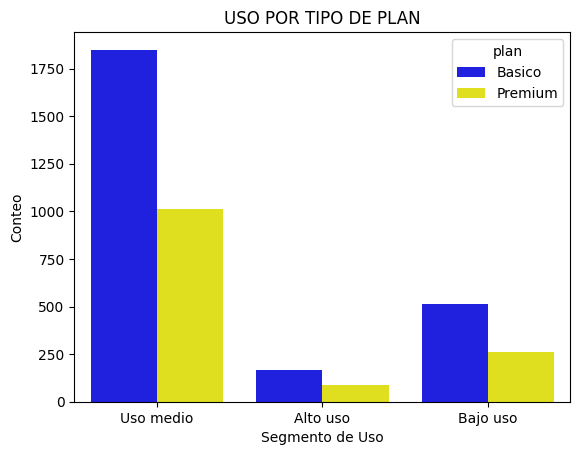

In [164]:
#Visualización de los segmentos por uso
sns.countplot(data=user_profile,x='grupo_uso',hue='plan',palette=['blue','yellow'])
plt.title('USO POR TIPO DE PLAN')
plt.xlabel('Segmento de Uso')
plt.ylabel('Conteo')
plt.show()


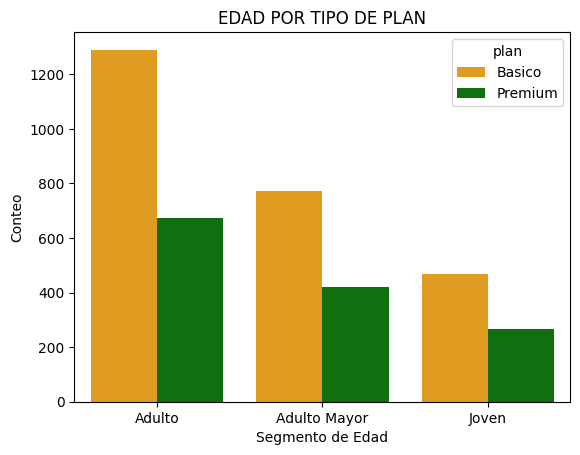

In [165]:
sns.countplot(data=user_profile,x='grupo_edad',hue='plan',palette=['orange','green'])
plt.title('EDAD POR TIPO DE PLAN')
plt.xlabel('Segmento de Edad')
plt.ylabel('Conteo')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**



### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
1. Calidad de los datos: problemas identificados
-reg_date             Fechas futuras (años > 2024)       Marcadas como NaT
-age                  Valores de -999 (sentinels)        Reemplazados con mediana
-duration             Nulos en registros tipo text       22076 filas — MAR estructural
-length               Nulos en registros tipo call       17896 filas — MAR estructural
-minutos_de_llamada   Outliers superiores(> 61.86 min)   Filtrados del análisis

🔍 **Segmentos por Edad**
-Segmento joven (20–40 años): predomina el plan básico. Menor capacidad adquisitiva o menor percepción de valor en el plan premium.
-Segmento maduro (40–50+ años): concentración mayor en plan premium. Mayor estabilidad económica y uso más intensivo del servicio


📊 **Segmentos por Nivel de Uso**
- Usuarios de bajo consumo: pocas llamadas (2–4), mensajes moderados, minutos reducidos. Perfil típico del plan básico.
- Usuarios de alto consumo: mayor frecuencia de llamadas (6+) y minutos acumulados (30–60). Se distribuyen entre ambos planes, pero predominan en premium.


➡️ Esto sugiere que ...
- El segmento más valioso es el usuario maduro (40+ años) con plan premium, por tres razones:

Ya paga más y tiene menor sensibilidad al precio.
Consume más minutos — el recurso más diferenciador entre planes.
Tiene mayor estabilidad como cliente a largo plazo.

Sin embargo, el segmento con mayor potencial de crecimiento son los usuarios básicos de 20–40 años con 6+ llamadas o 30+ minutos, que ya tienen comportamiento premium pero no han hecho el upgrade. Este grupo representa la oportunidad de conversión más directa.

💡 **Recomendaciones**
- Corto plazo — Conversión de básico a premium:

Identificar usuarios básicos con 6+ llamadas o 30+ minutos y ofrecerles un upgrade dirigido con incentivo de precio (descuento primer mes o precio escalonado).

- Mediano plazo — Captación del segmento joven:

Crear un plan premium junior con precio reducido para menores de 35 años, aprovechando que el comportamiento de uso ya existe pero la barrera es económica.

- Largo plazo — Nuevo plan de alto consumo:

Diseñar un plan empresarial o intensivo orientado a usuarios con más de 60 minutos mensuales, con beneficios diferenciados (prioridad de red, soporte dedicado, minutos ilimitados).

- Retención del segmento premium maduro:

Este segmento ya es rentable — la prioridad es no perderlo. Programas de lealtad, beneficios exclusivos o atención preferencial son palancas efectivas de retención.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`